## `Plan Of Execution - Blog Writing Agents (with Web Research)`

![Screenshot 2026-07-03 121546.png](<attachment:Screenshot 2026-07-03 121546.png>)
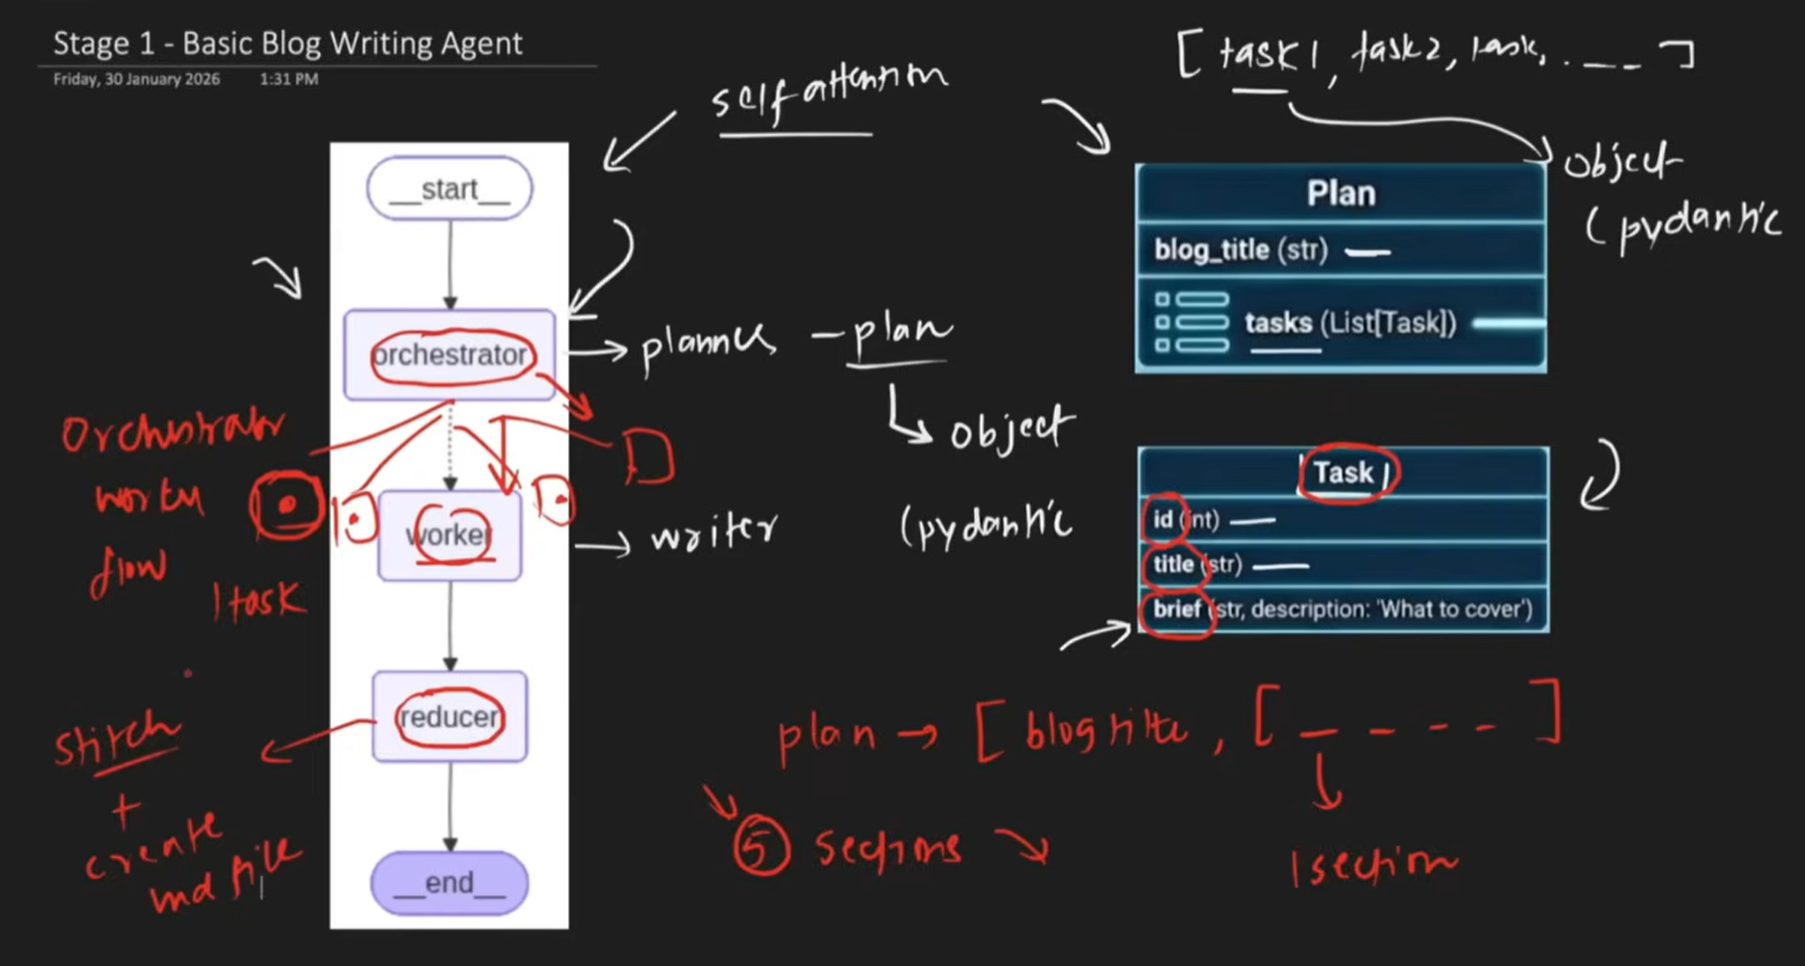

In [13]:
# Loading the libraries for the bwa analogy
from __future__ import annotations

import operator
import os
from datetime import date, timedelta
from pathlib import Path
from typing import TypedDict, Annotated, List, Literal, Optional

from pydantic import BaseModel, Field, ValidationError, validator
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

# loading the api reference key for tavily -> for research 
load_dotenv()

True

## `Building the classes for the state`

In [14]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3–5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120–450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use \'common_mistakes\' exactly once in the plan.",
    )

    # NEW: research-awareness flags. The orchestrator sets these so the worker
    # knows whether it is allowed/expected to cite evidence for this section.
    requires_research: bool = Field(
        default=False,
        description="True if this section depends on fresh/external facts (needs Evidence to be accurate).",
    )
    requires_citations: bool = Field(
        default=False,
        description="True if outside-world claims in this section must be backed by a Markdown source link.",
    )


class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]


# NEW: research schemas (ported from the research-fine-tuned notebook)
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # prefer ISO "YYYY-MM-DD"
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    reason: str
    queries: List[str] = Field(default_factory=list)
    max_results_per_query: int = Field(5, description="How many results to fetch per query (3–8).")


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


## `Building the main state of the graph`

In [15]:
# Now creating the main state of the graph
class State(TypedDict):
    topic: str

    # NEW: routing / research fields
    mode: str                      # "closed_book" | "hybrid" | "open_book"
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    as_of: str                     # ISO date, e.g. "2026-07-03"
    recency_days: int              # how far back evidence is allowed to be

    plan: Plan
    sections: Annotated[list[str], operator.add]
    final: str


## `Defining the model i will be using for the LLM brain`

In [16]:
llm = ChatOllama(
    model='llama3.1:latest'
)

## `Router node - decide upfront whether web research is needed`

In [17]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals, how something works).
- hybrid (needs_research=true):
  Mostly evergreen but benefits from up-to-date examples/tools/models/versions to stay accurate and useful.
- open_book (needs_research=true):
  Mostly volatile: "latest", "this week", rankings, pricing, news, releases, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal, specific search queries (avoid generic queries like just "AI").
- For open_book topics, phrase queries so they surface recent results.
"""

def router_node(state: State) -> dict:
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}\nAs-of date: {state["as_of"]}"),
        ]
    )

    # Default recency window based on mode
    if decision.mode == "open_book":
        recency_days = 7
    elif decision.mode == "hybrid":
        recency_days = 45
    else:
        recency_days = 3650

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
        "recency_days": recency_days,
    }


def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"


## `Research node - Tavily search + evidence synthesis`

In [18]:
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    """
    Uses TavilySearchResults (requires TAVILY_API_KEY in the environment / .env).
    Returns a list of dicts with normalized fields. Published date is often missing.
    """
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


def _iso_to_date(s: Optional[str]) -> Optional[date]:
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None


RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- Extract/normalize published_at as ISO (YYYY-MM-DD) if you can infer it from title/snippet.
  If you can\'t infer a date reliably, set published_at=null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])[:10]
    max_results = 6

    raw_results: List[dict] = []
    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(
                content=(
                    f"As-of date: {state["as_of"]}\n"
                    f"Recency days: {state["recency_days"]}\n\n"
                    f"Raw results:\n{raw_results}"
                )
            ),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    evidence = list(dedup.values())

    # Hard recency filter for open_book (weekly-news style) topics:
    # keep only items with a parseable ISO date within the recency window.
    mode = state.get("mode", "closed_book")
    if mode == "open_book":
        as_of = date.fromisoformat(state["as_of"])
        cutoff = as_of - timedelta(days=int(state["recency_days"]))
        fresh: List[EvidenceItem] = []
        for e in evidence:
            d = _iso_to_date(e.published_at)
            if d and d >= cutoff:
                fresh.append(e)
        evidence = fresh

    return {"evidence": evidence}


## `Building the orchestration node for the planning of the user input topic`

In [19]:
def orchestrator(state: State) -> dict:
    planner = llm.with_structured_output(Plan)
    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type=\'common_mistakes\'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., \'Show a minimal code snippet for X\', "
                    "\'Explain why Y fails under Z condition\', \'Add a checklist for production readiness\').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like \'Explain X\' or \'Discuss Y\'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Grounding rules (NEW):\n"
                    "- Mode closed_book: keep it evergreen; do not depend on Evidence.\n"
                    "- Mode hybrid: use Evidence only for up-to-date examples (versions/tools/releases) in bullets; "
                    "mark those sections requires_research=true and requires_citations=true.\n"
                    "- Mode open_book: this topic is fresh/volatile — base factual sections on Evidence; "
                    "mark every section that makes an outside-world claim as requires_research=true and "
                    "requires_citations=true. If Evidence is empty or thin, keep the plan honest and evergreen "
                    "rather than inventing facts.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(
                content=(
                    f"Topic: {state["topic"]}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state.get("as_of")} (recency_days={state.get("recency_days")})\n\n"
                    f"Evidence (ONLY use for fresh/outside-world claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )

    return {"plan": plan}


## `Fanout - send each section to a worker, carrying research context along`

In [20]:
def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"],
                "mode": state.get("mode", "closed_book"),
                "evidence": state.get("evidence", []),
            },
        )
        for task in state["plan"].tasks
    ]


## `Worker - writes one section, citing evidence when required`

In [21]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    mode = payload.get("mode", "closed_book")
    evidence: List[EvidenceItem] = payload.get("evidence", [])

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    # Compact evidence list the worker is allowed to cite from
    evidence_text = "None provided."
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date-unknown'}"
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
                    "Hard constraints:\n"
                    "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
                    "- Stay close to the Target words (±15%).\n"
                    "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n"
                    "- Start with a \'## <Section Title>\' heading.\n\n"
                    "Technical quality bar:\n"
                    "- Be precise and implementation-oriented (developers should be able to apply it).\n"
                    "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
                    "- When relevant, include at least one of:\n"
                    "  * a small code snippet (minimal, correct, and idiomatic)\n"
                    "  * a tiny example input/output\n"
                    "  * a checklist of steps\n"
                    "  * a diagram described in text (e.g., \'Flow: A -> B -> C\')\n"
                    "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
                    "- Call out edge cases / failure modes and what to do about them.\n"
                    "- If you mention a best practice, add the \'why\' in one sentence.\n\n"
                    "Grounding policy (NEW):\n"
                    "- If requires_citations is true: for any outside-world/fresh claim, attach a Markdown "
                    "source link using ONLY the URLs listed in Evidence below, formatted as ([Source](URL)).\n"
                    "- Do not invent facts, versions, dates, or URLs that are not in Evidence.\n"
                    "- If a claim needs a citation but no supporting Evidence is provided, write "
                    "\'Not found in provided sources.\' instead of guessing.\n"
                    "- Evergreen reasoning (concepts, intuition, general engineering advice) does not need citations.\n\n"
                    "Markdown style:\n"
                    "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
                    "- Avoid fluff. Avoid marketing language.\n"
                    "- If you include code, keep it focused on the bullet being addressed."
                )
            ),
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}


## `Reducer - merge sections and save the final blog`

In [22]:
def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}


## `Building the graph - router decides if research runs before planning`

In [23]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestration", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)
# router -> (research -> orchestration) OR (orchestration directly), then fanout to workers, then reduce


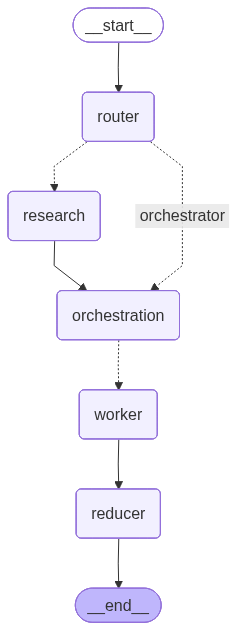

In [24]:
g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestration"})
g.add_edge("research", "orchestration")

g.add_conditional_edges("orchestration", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

# compiling the graph for the final workflow / flowchart
app = g.compile()
app


## `Runner - kicks off the graph with a topic + as-of date`

In [25]:
def run(topic: str, as_of: Optional[str] = None):
    if as_of is None:
        as_of = date.today().isoformat()

    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "as_of": as_of,
            "recency_days": 7,   # router may overwrite this
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    print("=" * 100)
    print("TOPIC:", topic)
    print("MODE:", out.get("mode"), "| NEEDS_RESEARCH:", out.get("needs_research"))
    print("QUERIES:", (out.get("queries") or [])[:6])
    print("EVIDENCE_COUNT:", len(out.get("evidence", [])))
    print("SECTIONS:", len(out["plan"].tasks))
    print("SAVED_MD_CHARS:", len(out.get("final", "")))
    print("=" * 100)

    return out


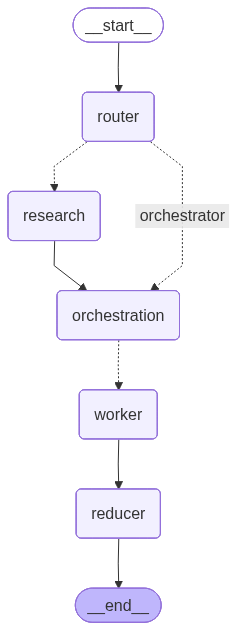

In [26]:
app

In [27]:
# evaluating the performance of the graph
output = run("Iran and Israel Conflict and Solutions")

ConnectError: [WinError 10061] No connection could be made because the target machine actively refused it

In [ ]:
# checking the output of the graph
output

{'topic': 'About Nepal : Country, Culture, and Travel Guide',
 'mode': 'open_book',
 'needs_research': True,
 'queries': [' nepal tourism industry 2026 ',
  ' nepal travel restrictions 2026 ',
  ' nepal cultural festivals 2024-2025 '],
 'evidence': [],
 'as_of': '2026-07-04',
 'recency_days': 7,
 'plan': Plan(blog_title='Nepal: Country, Culture, and Travel Guide', audience='travelers, tourists, cultural enthusiasts', tone='informative, engaging', tasks=[Task(id=1, title="Intro to Nepal's Geography and Climate", goal="Understand the country's geographical location and climate zones.", bullets=['Describe the Himalayan mountain range and its significance for Nepal.', 'Explain the different climate zones in Nepal, including tropical, subtropical, and alpine regions.', "Identify key cities and their corresponding climate conditions (e.g., Kathmandu's subtropical monsoon climate).", "Compare and contrast Nepal's geography with neighboring countries."], target_words=200, section_type='intro',